## Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn import hmm
from skfuzzy import control as ctrl
import skfuzzy as fuzz

In [16]:

# Simulated passenger boarding/alighting data
time_steps = 200
np.random.seed(42)  # For reproducibility
boarding_data = np.random.randint(0, 20, time_steps)
alighting_data = np.random.randint(0, 20, time_steps)

In [19]:
# Preparing the data for Hidden Markov Model for passenger behavior
X = np.column_stack([boarding_data, alighting_data])
n_components = 2  # Provides number of hidden states
hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=1000)
hmm_model.fit(X)
states = hmm_model.predict(X)

In [ ]:
# Fuzzy Logic System for decision making
boarding = ctrl.Antecedent(np.arange(0, 11, 1), 'boarding')
alighting = ctrl.Antecedent(np.arange(0, 11, 1), 'alighting')
crowd_level = ctrl.Consequent(np.arange(0, 101, 1), 'crowd_level')

boarding.automf(3)
alighting.automf(3)
crowd_level['low'] = fuzz.trimf(crowd_level.universe, [0, 25, 50])
crowd_level['medium'] = fuzz.trimf(crowd_level.universe, [25, 50, 75])
crowd_level['high'] = fuzz.trimf(crowd_level.universe, [50, 100, 100])

rule1 = ctrl.Rule(boarding['poor'] | alighting['poor'], crowd_level['low'])
rule2 = ctrl.Rule(boarding['average'] | alighting['average'], crowd_level['medium'])
rule3 = ctrl.Rule(boarding['good'] | alighting['good'], crowd_level['high'])

crowd_control = ctrl.ControlSystem([rule1, rule2, rule3])
crowd_simulation = ctrl.ControlSystemSimulation(crowd_control)

predicted_crowd_levels = []
for i in range(time_steps):
    crowd_simulation.input['boarding'] = boarding_data[i]
    crowd_simulation.input['alighting'] = alighting_data[i]
    crowd_simulation.compute()
    predicted_crowd_levels.append(crowd_simulation.output['crowd_level'])

## Visualization

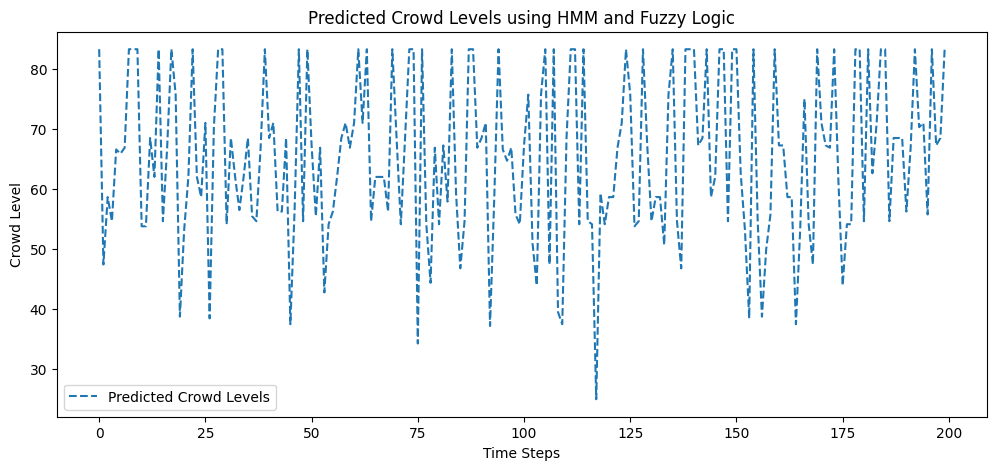

In [ ]:
# Visualization of hidden states
plt.figure(figsize=(12, 5))
plt.plot(predicted_crowd_levels, label='Predicted Crowd Levels', linestyle='dashed')
plt.xlabel("Time Steps")
plt.ylabel("Crowd Level")
plt.title("Predicted Crowd Levels using HMM and Fuzzy Logic")
plt.legend()
plt.show()



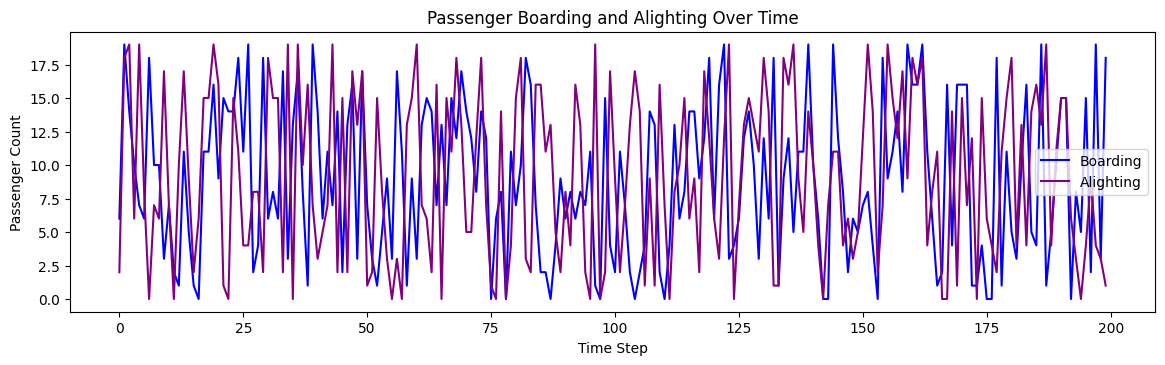

In [ ]:
# Plot boarding and alighting data for the different passenger counts
plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(boarding_data, label="Boarding", color="blue")
plt.plot(alighting_data, label="Alighting", color="purple")
plt.title("Passenger Boarding and Alighting Over Time")
plt.xlabel("Time Step")
plt.ylabel("Passenger Count")
plt.legend()

## Model evaluation

In [22]:
# Evaluates the log_likelihood
log_likelihood = hmm_model.score(X)
print(f"Log-likelihood of the model: {log_likelihood:.2f}")

Log-likelihood of the model: -1253.97


In [ ]:
# Model parameters
print("\nMeans (boarding, alighting) for each state:")
print(hmm_model.means_)
print("\nCovariances (boarding, alighting) for each state:")
print(hmm_model.covars_)
print("\nTransition matrix (probability of switching states):")
print(hmm_model.transmat_)


Means (boarding, alighting) for each state:
[[ 8.97631869  4.04726371]
 [ 8.72525139 15.1259843 ]]

Covariances (boarding, alighting) for each state:
[[[35.54690698  0.        ]
  [ 0.          9.76596953]]

 [[31.41978895  0.        ]
  [ 0.          7.48354749]]]

Transition matrix (probability of switching states):
[[0.57838058 0.42161942]
 [0.48387201 0.51612799]]


In [ ]:
#Analyzes 0 and 1 states characteristics
state_0_indices = np.where(states == 0)[0]
state_1_indices = np.where(states == 1)[0]

print("\nState 0 (Drop-off Dominant) Summary:")
print(f"Number of occurrences: {len(state_0_indices)}")
print(f"Average boarding: {boarding_data[state_0_indices].mean():.2f}")
print(f"Average alighting: {alighting_data[state_0_indices].mean():.2f}")

print("\nState 1 (Pick-up Dominant) Summary:")
print(f"Number of occurrences: {len(state_1_indices)}")
print(f"Average boarding: {boarding_data[state_1_indices].mean():.2f}")
print(f"Average alighting: {alighting_data[state_1_indices].mean():.2f}")


State 0 (Drop-off Dominant) Summary:
Number of occurrences: 105
Average boarding: 9.01
Average alighting: 3.85

State 1 (Pick-up Dominant) Summary:
Number of occurrences: 95
Average boarding: 8.69
Average alighting: 15.07
